# UNSW-NB15 dataset evaluation


In [11]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import average_precision_score, precision_score, recall_score, roc_auc_score, f1_score, accuracy_score, roc_curve
from sklearn.ensemble import ExtraTreesClassifier


In [12]:
PROJECT_ROOT = Path("..").resolve()
DATA_DIR = PROJECT_ROOT / "padme" / "src" / "main" / "resources" / "data"
OUT_DIR = DATA_DIR / "output"

TEST_PATH = OUT_DIR / "unsw_nb15_test.csv"

MODES = ["baseline", "padme", "random"]

DROP_COLS = ["__id", "label", "attack_cat", "proto", "service", "state"]

def load_retained(mode: str) -> list[Path]:
    d = OUT_DIR / mode
    return sorted(d.glob(f"{mode}_node*.csv"))

print("DATA_DIR:", DATA_DIR)
print("TEST_PATH exists:", TEST_PATH.exists())
for m in MODES:
    files = load_retained(m)
    print(m, "nodes:", len(files), "example:", (files[0].name if files else None))


DATA_DIR: C:\Users\Legion\Desktop\FEUP\Dissertação\PADME\feup-padme\padme\src\main\resources\data
TEST_PATH exists: True
baseline nodes: 5 example: baseline_node0.csv
padme nodes: 5 example: padme_node0.csv
random nodes: 5 example: random_node0.csv


In [13]:
def prepare_xy(df: pd.DataFrame):
    y = df["label"].astype(int).to_numpy()
    X = df.drop(columns=[c for c in DROP_COLS if c in df.columns], errors="ignore")
    X = X.apply(pd.to_numeric, errors="coerce").fillna(0.0)
    return X.to_numpy(dtype=np.float32), y

test_df = pd.read_csv(TEST_PATH)
Xt, yt = prepare_xy(test_df)

print("TEST shape:", Xt.shape, "positives:", int(yt.sum()), "ratio:", float(yt.mean()))


TEST shape: (5000, 31) positives: 3403 ratio: 0.6806


In [14]:
def model_ctor():
    return ExtraTreesClassifier(
        n_estimators=400,
        random_state=42,
        n_jobs=-1,
        class_weight=None
    )

def choose_threshold(model, X, y, recall_target=0.85, n_splits=5, random_state=42):
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    probs = np.zeros(len(y), dtype=np.float64)

    for tr, va in skf.split(X, y):
        m = model_ctor()
        m.fit(X[tr], y[tr])
        probs[va] = m.predict_proba(X[va])[:, 1]

    thresholds = np.quantile(probs, np.linspace(0.0, 1.0, 200))
    best_t = 0.5
    best_pr = -1.0

    for t in thresholds:
        pred = (probs >= t).astype(int)
        rec = recall_score(y, pred, zero_division=0)
        if rec + 1e-12 < recall_target:
            continue
        pr = precision_score(y, pred, zero_division=0)
        if pr > best_pr:
            best_pr = pr
            best_t = float(t)

    if best_pr < 0:
        best_t = float(np.quantile(probs, 0.99))

    return best_t

def recall_at_fpr(yt, p, fpr_target):
    fpr, tpr, _ = roc_curve(yt, p)
    i = np.searchsorted(fpr, fpr_target, side="right") - 1
    i = np.clip(i, 0, len(tpr) - 1)
    return float(tpr[i])

def eval_one(model, X_train, y_train, Xt, yt, recall_target=0.85):
    t = choose_threshold(model, X_train, y_train, recall_target=recall_target)
    model.fit(X_train, y_train)
    p = model.predict_proba(Xt)[:, 1]
    pred = (p >= t).astype(int)

    return {
        "threshold": t,
        "pr_auc": average_precision_score(yt, p),
        "recall_at_fpr_1pct": recall_at_fpr(yt, p, 0.01),
        "recall_at_fpr_0_1pct": recall_at_fpr(yt, p, 0.001),
        "roc_auc": roc_auc_score(yt, p),
        "precision": precision_score(yt, pred, zero_division=0),
        "recall": recall_score(yt, pred, zero_division=0),
        "f1": f1_score(yt, pred, zero_division=0),
        "acc": accuracy_score(yt, pred),
    }


In [15]:
rows = []

for mode in MODES:
    files = load_retained(mode)
    if not files:
        raise RuntimeError(f"No retained node files for mode={mode}")

    for node_id, fp in enumerate(files):
        df = pd.read_csv(fp)
        Xn, yn = prepare_xy(df)

        res = eval_one(model_ctor(), Xn, yn, Xt, yt, recall_target=0.85)
        res["mode"] = mode
        res["node"] = node_id
        res["train_rows"] = len(df)
        res["train_pos"] = int(yn.sum())
        rows.append(res)

results = pd.DataFrame(rows).sort_values(["mode", "node"]).reset_index(drop=True)
results


,threshold,pr_auc,recall_at_fpr_1pct,recall_at_fpr_0_1pct,roc_auc,precision,recall,f1,acc,mode,node,train_rows,train_pos
0,0.455000,0.985731,0.699089,0.319424,0.972562,0.988760,0.775492,0.869236,0.8412,baseline,0,18816,3777
1,0.437500,0.985736,0.691449,0.312665,0.972604,0.987407,0.783426,0.873669,0.8458,baseline,1,18890,3755
2,0.470000,0.985767,0.687629,0.285630,0.972714,0.989065,0.770790,0.866391,0.8382,baseline,2,18866,3796
3,0.450226,0.985981,0.711431,0.270350,0.973200,0.989179,0.779019,0.871609,0.8438,baseline,3,18884,3771
4,0.465000,0.986225,0.714370,0.316192,0.973536,0.990203,0.772260,0.867756,0.8398,baseline,4,18868,3809
5,0.422500,0.981362,0.575962,0.317073,0.964929,0.979377,0.711725,0.824370,0.7936,padme,0,1000,240
6,0.405138,0.980990,0.461358,0.339994,0.965229,0.966035,0.794005,0.871613,0.8408,padme,1,1000,218
7,0.430000,0.981338,0.580664,0.431384,0.964085,0.970794,0.732589,0.835036,0.8030,padme,2,1000,257
8,0.425276,0.982367,0.565677,0.356450,0.966355,0.979398,0.726418,0.834149,0.8034,padme,3,1000,230
9,0.457337,0.982069,0.634440,0.385836,0.965099,0.974178,0.731707,0.835711,0.8042,padme,4,1000,255


In [20]:
summary = results.groupby("mode").agg(
    nodes=("node","count"),
    train_rows_mean=("train_rows","mean"),
    pr_auc_mean=("pr_auc","mean"),
    pr_auc_std=("pr_auc","std"),
    roc_auc_mean=("roc_auc","mean"),
    roc_auc_std=("roc_auc","std"),
    precision_mean=("precision","mean"),
    precision_std=("precision","std"),
    recall_mean=("recall","mean"),
    recall_std=("recall","std"),
    recall_at_fpr_1pct_mean=("recall_at_fpr_1pct","mean"),
    recall_at_fpr_1pct_std=("recall_at_fpr_1pct","std"),
    f1_mean=("f1","mean"),
    f1_std=("f1","std"),
    acc_mean=("acc","mean"),
    acc_std=("acc","std"),
).reset_index()

summary


,mode,nodes,train_rows_mean,pr_auc_mean,pr_auc_std,roc_auc_mean,roc_auc_std,precision_mean,precision_std,recall_mean,recall_std,recall_at_fpr_1pct_mean,recall_at_fpr_1pct_std,f1_mean,f1_std,acc_mean,acc_std
0,baseline,5,18864.8,0.985888,0.000215,0.972923,0.000427,0.988923,0.001006,0.776197,0.005135,0.700793,0.011843,0.869732,0.002930,0.84176,0.003054
1,padme,5,1000.0,0.981625,0.000571,0.965140,0.000813,0.973957,0.005740,0.739289,0.031708,0.563620,0.063088,0.840176,0.018171,0.80900,0.018295
2,random,5,1000.0,0.978497,0.002703,0.960748,0.004538,0.967753,0.008220,0.765619,0.033421,0.520717,0.059774,0.854471,0.018193,0.82296,0.018527


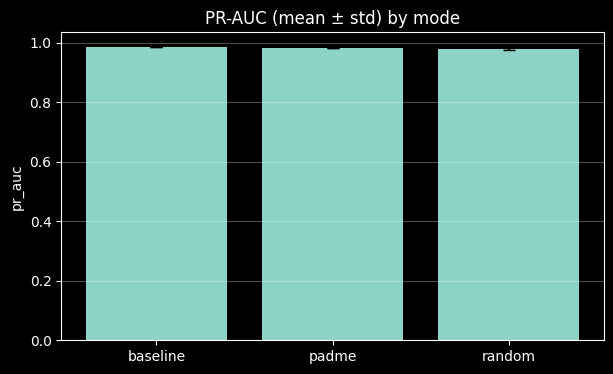

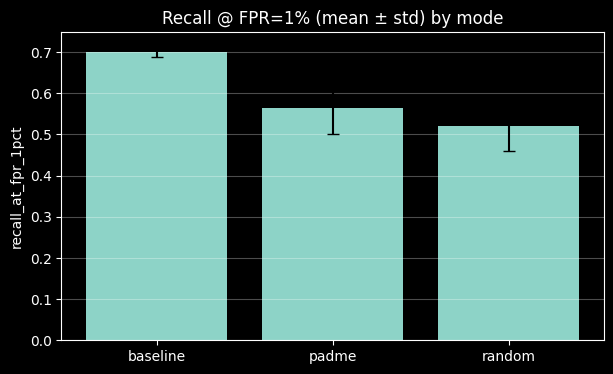

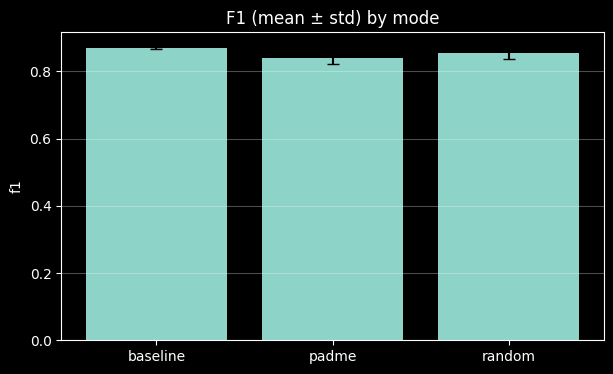

In [21]:
def bar_with_err(metric_mean, metric_std, title):
    x = np.arange(len(summary["mode"]))
    plt.figure(figsize=(7,4))
    plt.bar(x, summary[metric_mean].to_numpy(),
            yerr=summary[metric_std].fillna(0).to_numpy(), capsize=4)
    plt.xticks(x, summary["mode"].to_list())
    plt.title(title)
    plt.ylabel(metric_mean.replace("_mean",""))
    plt.grid(axis="y", alpha=0.3)
    plt.show()

bar_with_err("pr_auc_mean", "pr_auc_std", "PR-AUC (mean ± std) by mode")
bar_with_err("recall_at_fpr_1pct_mean", "recall_at_fpr_1pct_std", "Recall @ FPR=1% (mean ± std) by mode")
bar_with_err("f1_mean", "f1_std", "F1 (mean ± std) by mode")